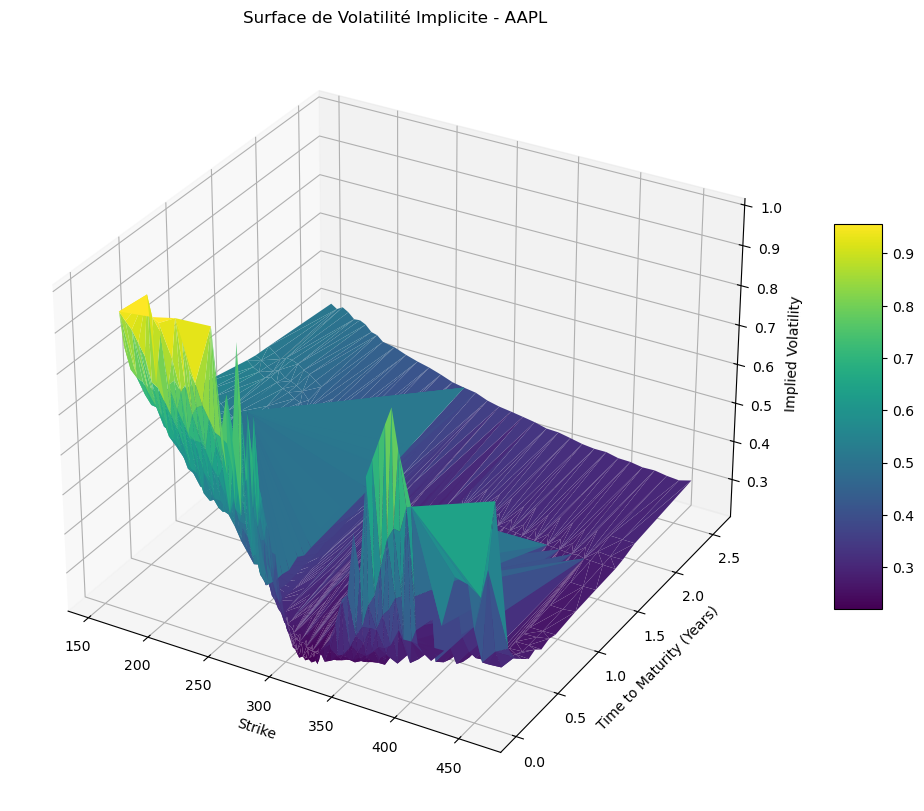

In [6]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Téléchargement des données Apple
apple = yf.Ticker("AAPL")

# Prix spot actuel
spot = apple.history(period="1d")["Close"].iloc[-1]

# Toutes les maturités disponibles
expirations = apple.options

# Liste pour stocker les calls
all_calls = []

# Boucle sur les maturités
for maturity in expirations:
    
    chain = apple.option_chain(maturity)
    
    calls = chain.calls.copy()
    
    # Ajouter expiration
    calls["expiration"] = maturity
    
    # Colonnes utiles
    calls = calls[["expiration", "strike", "impliedVolatility"]]
    
    all_calls.append(calls)

# Concaténation
calls_df = pd.concat(all_calls, ignore_index=True)

# Renommer IV
calls_df = calls_df.rename( columns={"impliedVolatility": "iv"})

# Supprimer les valeurs manquantes
calls_df = calls_df.dropna(subset=["iv"])

# Filtrer IV aberrantes
calls_df = calls_df[(calls_df["iv"] > 0.05) &(calls_df["iv"] < 1.0)]

# Filtrer strikes trop éloignés du spot
calls_df = calls_df[(calls_df["strike"] > 0.5 * spot) & (calls_df["strike"] < 1.5 * spot)]


# Temps jusqu'à maturité

calls_df["expiration"] = pd.to_datetime(calls_df["expiration"])

today = pd.Timestamp.today()

calls_df["ttm"] = (calls_df["expiration"] - today).dt.days / 365

# Garder maturités positives
calls_df = calls_df[calls_df["ttm"] > 0]

# Préparer les axes

X = calls_df["strike"]
Y = calls_df["ttm"]
Z = calls_df["iv"]

# Représentation graphique 3D

fig = plt.figure(figsize=(14,10))

ax = fig.add_subplot(111, projection="3d")

surface = ax.plot_trisurf(X, Y, Z, cmap="viridis", edgecolor="none")

# Labels
ax.set_xlabel("Strike")
ax.set_ylabel("Time to Maturity (Years)")
ax.set_zlabel("Implied Volatility")

ax.set_title("Surface de Volatilité Implicite - AAPL")

# Barre de couleurs
fig.colorbar(surface, shrink=0.5, aspect=8)
plt.savefig("image_volatility_surface.png", dpi=300)
plt.show()